# วิเคราะห์พฤติกรรมเพื่อประเมินความเสี่ยงและจัดกลุ่มลูกค้า
# (Credit Risk Profiling & Customer Segmentation)

## Data: https://www.kaggle.com/datasets/arjunbhasin2013/ccdata

## ข้อมูลพฤติกรรมการใช้บัตรเครดิตของลูกค้า โดยเก็บข้อมูลในระดับลูกค้า (customer level)

## มีตัวแปรพฤติกรรม 18 ตัวแปร

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# โหลด library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

# Data Acquisition

In [4]:
# โหลดข้อมูล
# Mount to Google Drive
from google.colab import drive
drive.mount('/content/drive')
CusData = pd.read_excel("/content/drive/MyDrive/Credit Risk Analysis Portfolio/Credit Card Dataset for Clustering.xlsx")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# เรียก 5 rows แรกมาดู
CusData.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [6]:
# เพื่อดูมิติของข้อมูล จำนวนแถวและคอลัมน์
CusData.shape

(8950, 18)

### Data Description
* CUST_ID : Identification of Credit Card holder (Categorical)
* BALANCE : Balance amount left in their account to make purchases
* BALANCE_FREQUENCY : How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated)
* PURCHASES : Amount of purchases made from account
* ONEOFF_PURCHASES : Maximum purchase amount done in one-go
* INSTALLMENTS_PURCHASES : Amount of purchase done in installment
* CASH_ADVANCE : Cash in advance given by the user
* PURCHASES_FREQUENCY : How frequently the Purchases are being made, score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased)
* ONEOFFPURCHASESFREQUENCY : How frequently Purchases are happening in one-go (1 = frequently purchased, 0 = not frequently purchased)
* PURCHASESINSTALLMENTSFREQUENCY : How frequently purchases in installments are being done (1 = frequently done, 0 = not frequently done)
* CASHADVANCEFREQUENCY : How frequently the cash in advance being paid
* CASHADVANCETRX : Number of Transactions made with "Cash in Advanced"
* PURCHASES_TRX : Numbe of purchase transactions made
* CREDIT_LIMIT : Limit of Credit Card for user
* PAYMENTS : Amount of Payment done by user
* MINIMUM_PAYMENTS : Minimum amount of payments made by user
* PRCFULLPAYMENT : Percent of full payment paid by user
* TENURE : Tenure of credit card service for user

# Data Preparation

In [7]:
CusData_cleaned = CusData.iloc[:,1:] # เพื่อเอาคอลัมน์ CUST_ID ออก

In [8]:
CusData_cleaned.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## Checking and handling duplicate data

In [9]:
CusData_cleaned.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
8945,False
8946,False
8947,False
8948,False


In [10]:
CusData_cleaned.duplicated().sum()

np.int64(0)

ไม่มี duplicate values

## Checking and handling inconsistent Datatypes

In [11]:
# ตรวจสอบ datatype
CusData_cleaned.dtypes

,0
BALANCE,float64
BALANCE_FREQUENCY,float64
PURCHASES,float64
ONEOFF_PURCHASES,float64
INSTALLMENTS_PURCHASES,float64
CASH_ADVANCE,float64
PURCHASES_FREQUENCY,float64
ONEOFF_PURCHASES_FREQUENCY,float64
PURCHASES_INSTALLMENTS_FREQUENCY,float64
CASH_ADVANCE_FREQUENCY,float64


In [12]:
# หาค่าที่แตกต่างในแต่ละคอลัมน์
for col in CusData_cleaned.select_dtypes(include=['object']).columns:
  print(f'{col}: {CusData_cleaned[col].unique()}')

ไม่มีคอลัมน์ไหนที่มีชนิดของข้อมูลแตกต่าง

## Checking and handling missing data

In [13]:
# หา Missing Value and Data Type
CusData_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CREDIT

In [14]:
CusData_cleaned.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


In [15]:
'''
 0   CUST_ID                           8950 non-null   DataType = object
 1   BALANCE                           8950 non-null   DataType = float64
 2   BALANCE_FREQUENCY                 8950 non-null   DataType = float64
 3   PURCHASES                         8950 non-null   DataType = float64
 4   ONEOFF_PURCHASES                  8950 non-null   DataType = float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   DataType = float64
 6   CASH_ADVANCE                      8950 non-null   DataType = float64
 7   PURCHASES_FREQUENCY               8950 non-null   DataType = float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   DataType = float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   DataType = float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   DataType = float64
 11  CASH_ADVANCE_TRX                  8950 non-null   DataType = int64
 12  PURCHASES_TRX                     8950 non-null   DataType = int64
 13  CREDIT_LIMIT                      8949 non-null   DataType = float64
 14  PAYMENTS                          8950 non-null   DataType = float64
 15  MINIMUM_PAYMENTS                  8637 non-null   DataType = float64
 16  PRC_FULL_PAYMENT                  8950 non-null   DataType = float64
 17  TENURE                            8950 non-null   DataType = int64
dtypes: float64(14), int64(3), object(1)
'''
'''
คอลลัมน์ที่ไม่มี Missing Value คือ
CUST_ID, BALANCE, BALANCE_FREQUENCY, PURCHASES, ONEOFF_PURCHASES,
INSTALLMENTS_PURCHASES, CASH_ADVANCE, PURCHASES_FREQUENCY, ONEOFF_PURCHASES_FREQUENCY,
PURCHASES_INSTALLMENTS_FREQUENCY, CASH_ADVANCE_FREQUENCY,
CASH_ADVANCE_TRX, PURCHASES_TRX, PAYMENTS, PRC_FULL_PAYMENT, TENURE
'''

'\nคอลลัมน์ที่ไม่มี Missing Value คือ\nCUST_ID, BALANCE, BALANCE_FREQUENCY, PURCHASES, ONEOFF_PURCHASES,\nINSTALLMENTS_PURCHASES, CASH_ADVANCE, PURCHASES_FREQUENCY, ONEOFF_PURCHASES_FREQUENCY,\nPURCHASES_INSTALLMENTS_FREQUENCY, CASH_ADVANCE_FREQUENCY,\nCASH_ADVANCE_TRX, PURCHASES_TRX, PAYMENTS, PRC_FULL_PAYMENT, TENURE\n'

คอลัมน์ CREDIT_LIMIT 8949 มี Missing Value 1 cell

คอลัมน์ MINIMUM_PAYMENTS 8637 มี Missing Value 313 cells

In [16]:
# แทนค่า Missing Value ด้วยค่าเฉลี่ยของข้อมูลคอลลัมน์นั้น เนื่องจาก CREDIT_LIMIT และ MINIMUM_PAYMENTS เป็นตัวเลข
CusData_cleaned['CREDIT_LIMIT'].fillna(CusData_cleaned['CREDIT_LIMIT'].median(), inplace=True)

/tmp/ipykernel_6225/77664703.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  CusData_cleaned['CREDIT_LIMIT'].fillna(CusData_cleaned['CREDIT_LIMIT'].median(), inplace=True)


In [17]:
CusData_cleaned['MINIMUM_PAYMENTS'].fillna(CusData_cleaned['MINIMUM_PAYMENTS'].median(), inplace=True)

/tmp/ipykernel_6225/2665546336.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  CusData_cleaned['MINIMUM_PAYMENTS'].fillna(CusData_cleaned['MINIMUM_PAYMENTS'].median(), inplace=True)


In [18]:
CusData_cleaned.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


No missing data

# EDA and Data Visualization

Problem Framing
- ดูพฤติกรรมการใช้จ่ายบัตรเครดิต
- ปัจจัยที่ส่งผลต่อพฤติกรรมการใช้บัตรเครดิต


In [19]:
# สร้างตารางเพื่อดูสถิติพื้นฐานของแต่ละ column
'''
จะได้ row คือ
count = จำนวนข้อมูลที่ไม่ซ้ำ
mean = ค่าเฉลี่ย
std = ส่วนเบี่ยงเบนมาตรฐาน
min = ค่าต่ำสุด
25% = 25% ของข้อมูล หรือ ควอร์ไทล์ที่ 1
50% = 50% ของข้อมูล หรือ ควอร์ไทล์ที่ 2
75% = 75% ของข้อมูล หรือ ควอร์ไทล์ที่ 3
max = ค่าที่สูงสุด
'''
df_credit = CusData_cleaned.copy()
df_credit.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.282473,1733.143852,844.906767,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.646702,2895.063757,2332.792322,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,170.857654,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,788.713501,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


ค่าเฉลี่ยของ balance คือ 1564.4748 แต่ค่าสูงสุด คือ 19043.1385 ซึ่งเป็นช่วงที่กว้าง

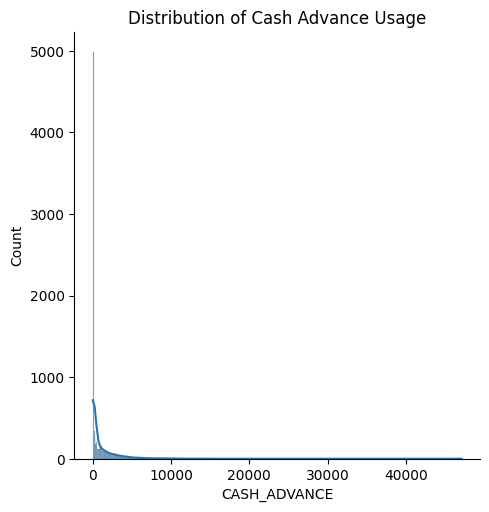

In [20]:
#ดูจำนวนลูกค้าตามการใช้ Cash Advance
sb.displot(x = 'CASH_ADVANCE', data = df_credit, kde=True)
plt.title("Distribution of Cash Advance Usage")
plt.show()

ลูกค้าที่มีการถอนเงินสดมีน้อยมาก

ลูกค้าที่ถอนเงินสดก็จะถอนจำนวนที่สูง

มีปัญหาขาดสภาพคล่องทางการเงิน

In [21]:
# ความถี่ของลูกค้าแบ่งตาม TENURE
df_credit.groupby(['TENURE'])['TENURE'].count()

,TENURE
TENURE,
6,204
7,190
8,196
9,175
10,236
11,365
12,7584


In [22]:
# ลูกค้าเป็นร้อยละแบ่งตาม TENURE
df_credit.groupby(['TENURE'])['TENURE'].count()/len(df_credit)

,TENURE
TENURE,
6,0.022793
7,0.021229
8,0.021899
9,0.019553
10,0.026369
11,0.040782
12,0.847374


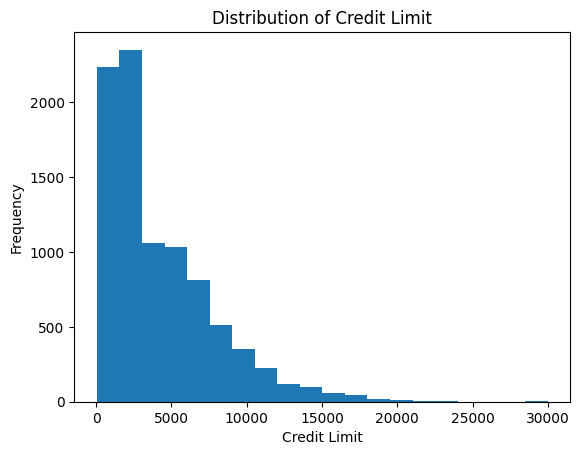

In [23]:
# Distribution of Credit Limit การกระจายของวงเงินเครดิต
plt.hist(df_credit['CREDIT_LIMIT'], bins=20)
plt.xlabel('Credit Limit')
plt.ylabel('Frequency')
plt.title("Distribution of Credit Limit")
plt.show()

บอกได้ว่าลูกค้าส่วนใหญ่มีวงเงินเครดิตที่ต่ำ

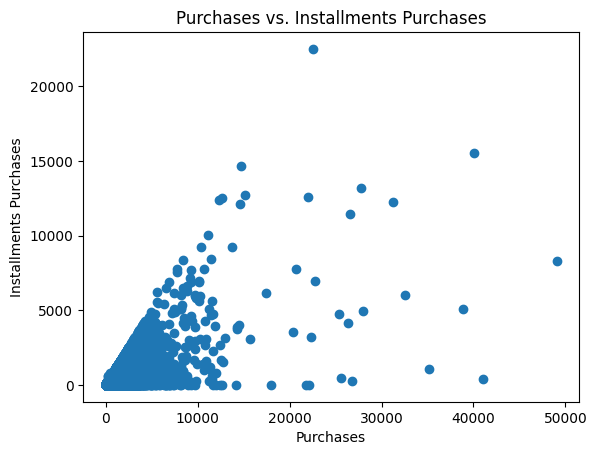

In [24]:
# Scatter plot แสดงความสัมพันธ์ระหว่าง PURCHASES และ INSTALLMENTS_PURCHASES การผ่อน
plt.scatter(df_credit['PURCHASES'], df_credit['INSTALLMENTS_PURCHASES'])
plt.xlabel('Purchases')
plt.ylabel('Installments Purchases')
plt.title("Purchases vs. Installments Purchases")
plt.show()

PURCHASES ยอดซื้อทั้งหมด กับ INSTALLMENTS_PURCHASES ซื้อแบบผ่อนชำระ มีความสัมพันธ์เชิงบวก

คือเมื่อลูกค้ามียอดซื้อที่เยอะ ยอดซื้อแบบผ่อนก็มากขึ้นด้วย
แต่ก็มีลูกค้าที่ยอดซื้อเยอะแต่ไม่ได้ซื้อแบบผ่อนชำระ

และลูกค้าที่ซื้อไม่เยอะแต่ซื้อแบบผ่อนชำระ

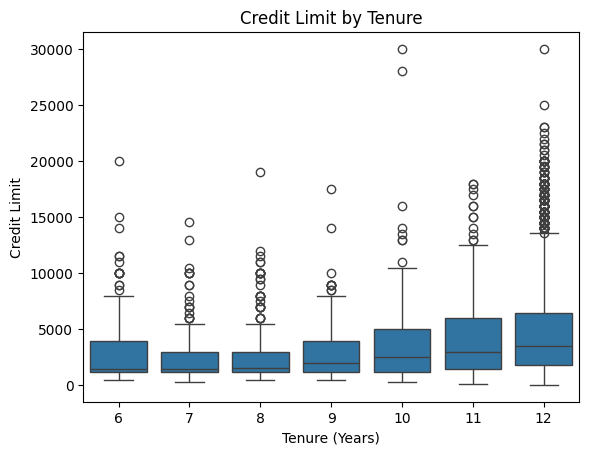

In [25]:
# Box plot แสดงความสัมพันธ์ระหว่าง TENURE และ CREDIT_LIMIT
sb.boxplot(x=df_credit['TENURE'], y=df_credit['CREDIT_LIMIT'])
plt.xlabel('Tenure (Years)')
plt.ylabel('Credit Limit')
plt.title("Credit Limit by Tenure")
plt.show()

เมื่อวงเงินเครดิต มีแนวโน้มที่สูงขึ้นตามเวลาการถือบัตร

ลูกค้าที่ถือบัตร 12 ปี
จะมีวงเงินเครดิตที่กระจายมาก

ลูกค้าที่ถือบัตรนานก็จะมีวงเงินเครดิตที่สูง

# Correlation Analysis

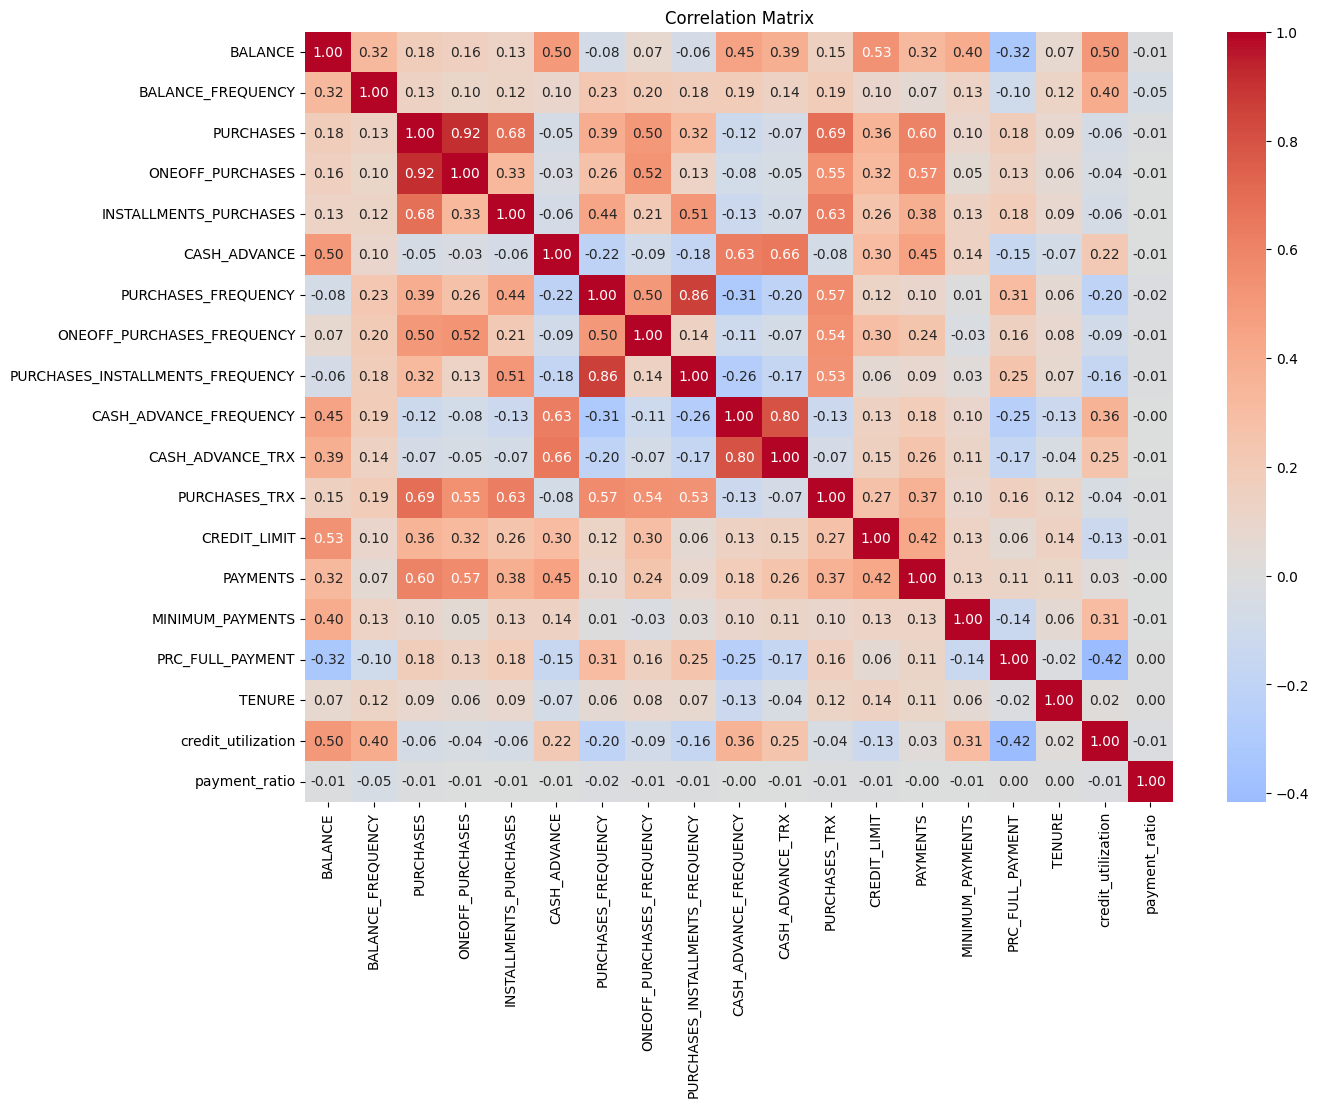

In [37]:
# Correlation Matrix
numeric_df = df_credit.select_dtypes(include=np.number) # col อื่นจะได้ไม่ปน
corr_matrix = numeric_df.corr()
plt.figure(figsize=(14,10))
sb.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

Strong Positive Correlations

- PURCHASES <> ONEOFF PERCHASES
- PURCHASES_INSTALLMENTS_FREQUENCY <> PURCHASES_FREQUENCY
- CASH_ADVANCE_TRX <> CASH_ADVANCE_FREQUENCY

Strong Negative Correlations

- PRC_FULL_PAYMENT <> BALANCE
- PRC_FULL_PAYMENT <> credit utilization

BALANCE มีความสัมพันธ์เชิงบวกทั้ง PURCHASES, CASH_ADVANCE และ CREDIT_LIMIT


- BALANCE กับ CASH_ADVANCE มีขนาดของความสัมพันธ์เท่ากับ 0.5

คือ ลูกค้าที่มียอดเงินคงเหลือมากก็มีการกดเงินสดมากด้วย

- BALANCE กับ CREDIT_LIMIT มีขนาดของความสัมพันธ์เท่ากับ 0.53

คือ ลูกค้าที่มียอดเงินคงเหลือมากก็มีวงเงินเครดิตสูงด้วย อาจทำให้จ่ายมากขึ้นได้

- PURCHASES กับ CREDIT_LIMIT มีขนาดของความสัมพันธ์เท่ากับ 0.36

คือ การซื้อสินค้าที่มากจะมีวงเงินเครดิตที่มากไปด้วย
แต่ไม่ได้สัมพันธ์อย่างเห็นได้ชัด

- PURCHASES กับ CASH_ADVANCE มีความสัมพันธ์เชิงลบขนาด -0.05

คือ การซื้อสินค้ามีความสัมพันธ์กับการจ่ายเงินสดที่ต่ำ
ลูกค้าที่มีบัตรเพื่อซื้อสินค้าก็จะไม่ค่อยถอนเงินสด

[ที่เหลือเป็นตัวแปรที่ไม่ได้มีความสัมพันธ์กันมาก]

เช่น BALANCE กับ PURCHASES มีขนาดของความสัมพันธ์เท่ากับ 0.18

สัมพันธ์เชิงบวกแต่ต่ำ คือการซื้อสินค้าไม่ได้แสดงถึงการมียอดเงินคงเหลือ

- CREDIT_LIMIT เป็นตัวแปรหลักที่ทำให้เกิดการมียอดเงินคงเหลือและยอดซื้อสินค้า




# Credit Utilization & Payment Ratio Analysis

In [27]:
# Credit Utilization Analysis
# อัตราส่วนยอดหนี้ต่อวงเงิน
# ตัวหาร > 0

df_credit['credit_utilization'] = np.where(
    df_credit['CREDIT_LIMIT'] > 0,
    df_credit['BALANCE'] / df_credit['CREDIT_LIMIT'], 0
)

In [51]:
# Payment Ratio Analysis
df_credit['payment_ratio'] = np.where(
    df_credit['BALANCE'] >= 100, # ถ้าลูกค้ามี balance=0.01 ทำให้ ratio มีค่าสูงเกินไป ทั้งที่ลูกค้าไม่ได้มีความผิดปกติอะไร
    df_credit['PAYMENTS'] / df_credit['BALANCE'], 0
)

In [52]:
df_credit['payment_ratio'].describe()

,payment_ratio
count,8950.000000
mean,1.969415
std,4.321567
min,0.000000
25%,0.117945
50%,0.383546
75%,1.757727
max,126.991662


Text(0.5, 1.0, 'Distribution of Credit Utilization Ratio')

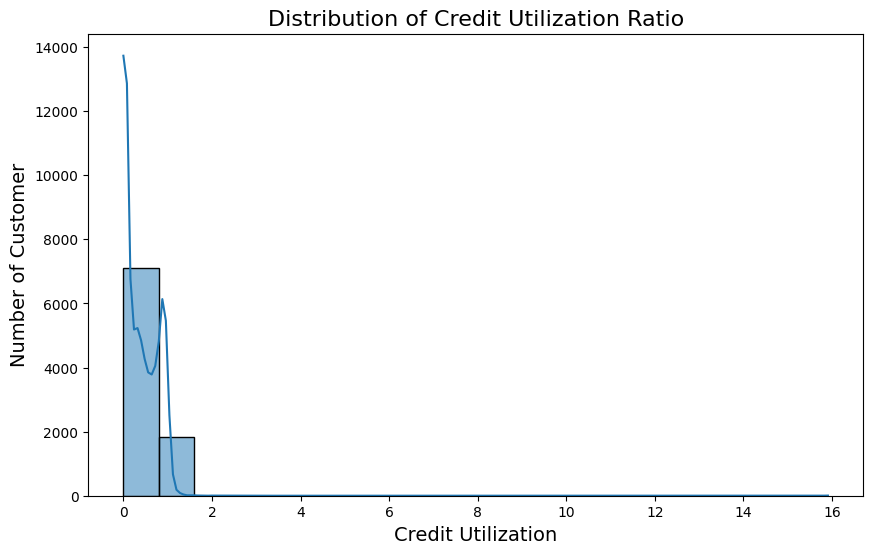

In [53]:
plt.figure(figsize=(10, 6))
sb.histplot(df_credit['credit_utilization'], bins=20, kde=True)
plt.xlabel('Credit Utilization', fontsize=14)
plt.ylabel('Number of Customer', fontsize=14)
plt.title('Distribution of Credit Utilization Ratio', fontsize=16)

ลูกค้าที่ Credit Utilization มากกว่าประมาณ 0.8 (80%) ใช้เงินเกินวงเงิน

Text(0.5, 1.0, 'Distribution of Payment Ratio')

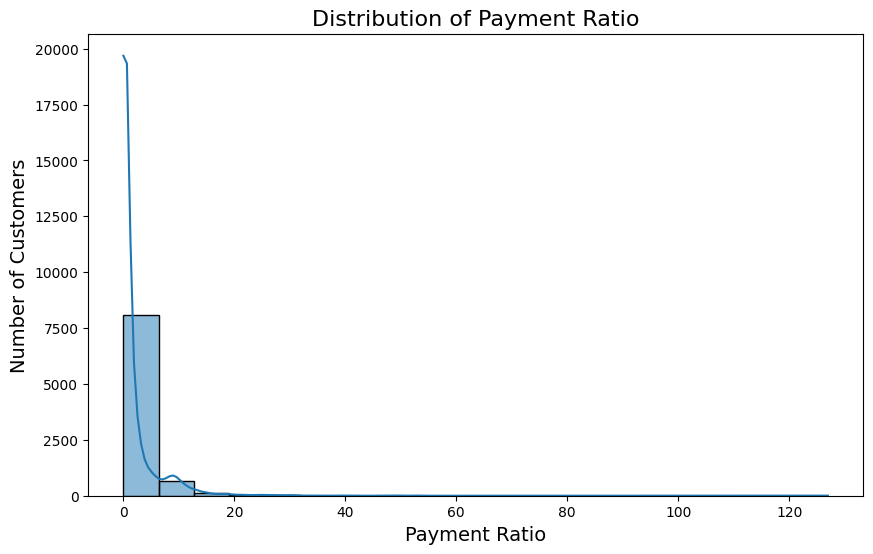

In [54]:
plt.figure(figsize=(10, 6))
sb.histplot(df_credit['payment_ratio'], bins=20, kde=True)
plt.xlabel('Payment Ratio', fontsize=14)
plt.ylabel('Number of Customers', fontsize=14)
plt.title('Distribution of Payment Ratio', fontsize=16)

พฤติกรรมการชำระเงินมีความเบี่ยงเบน เห็นได้ว่าลูกค้าส่วนน้อยที่ชำระยอดค้างชำระทั้งหมด

Text(0, 0.5, 'Payment Ratio')

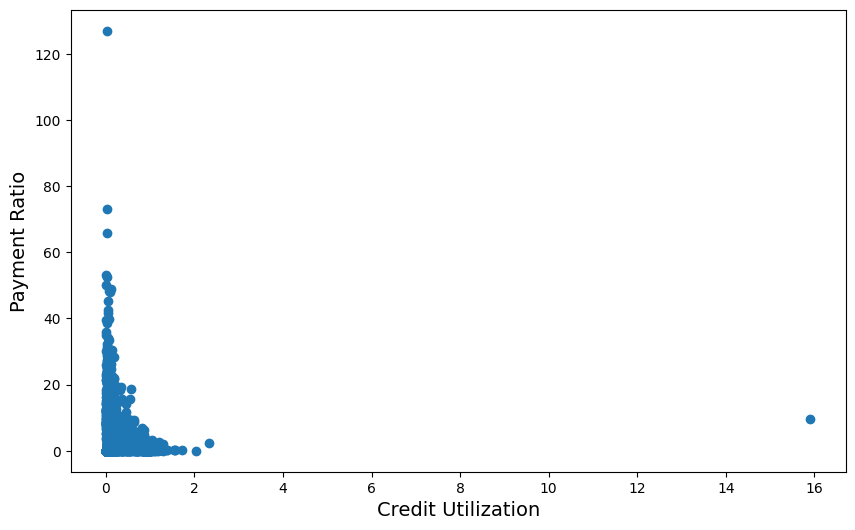

In [55]:
# Utilization vs Payment Ratio
plt.figure(figsize=(10, 6))
plt.scatter(df_credit['credit_utilization'], df_credit['payment_ratio'])
plt.xlabel('Credit Utilization', fontsize=14)
plt.ylabel('Payment Ratio', fontsize=14)

ลูกค้าที่มีอัตราการใช้สินเชื่อสูงและอัตราการชำระเงินต่ำ อาจจะมีความเสี่ยงเครดิตสูง

# Risk Profiling

In [56]:
# Risk Segment Distribution
util_q75 = df_credit['credit_utilization'].quantile(0.75)
util_q90 = df_credit['credit_utilization'].quantile(0.90)
payment_q25 = df_credit['payment_ratio'].quantile(0.25)
payment_q50 = df_credit['payment_ratio'].quantile(0.50)

print(util_q75)
print(util_q90)
print(payment_q25)
print(payment_q50)

0.7175712838642857
0.9198875859880953
0.11794451333283543
0.3835458476962171


In [57]:
# จัดกลุ่มลูกค้าตามความเสี่ยง
# จัดกลุ่มความเสี่ยง (Risk Profiling)
def categorize_risk(row):
    util = row['credit_utilization']
    pay = row['payment_ratio']

    # ถ้าใช้วงเงินเยอะมาก (90%) และ จ่ายคืนน้อย (25%)
    if util >= util_q90 and pay <= payment_q25:
        return 'High Risk'

    # ถ้าใช้วงเงินเริ่มเยอะ (75%) และ จ่ายคืนไม่ถึงครึ่ง (50%)
    elif util >= util_q75 and pay <= payment_q50:
        return 'Medium Risk'

    # นอกนั้นปกติ
    else:
        return 'Low Risk'

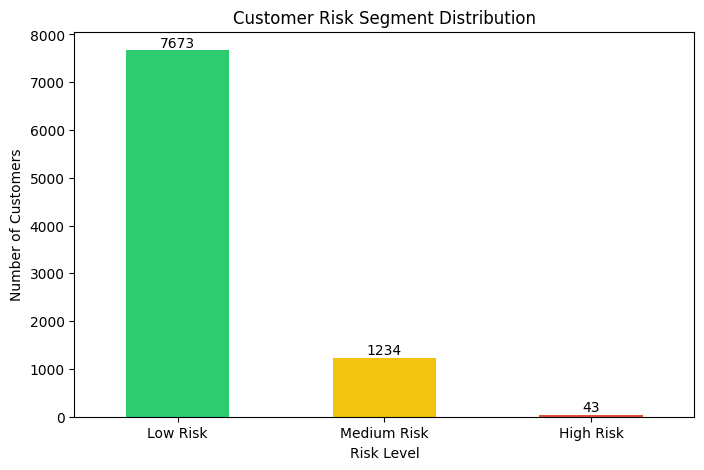

In [58]:
# apply ฟังก์ชันไปใช้กับข้อมูลทุกแถว
df_credit['risk_level'] = df_credit.apply(categorize_risk, axis=1)

# นับจำนวนลูกค้าแต่ละกลุ่ม
risk_counts = df_credit['risk_level'].value_counts()

# เรียงลำดับ Low -> Medium -> High
risk_counts = risk_counts[['Low Risk', 'Medium Risk', 'High Risk']]
colors = ['#2ecc71', '#f1c40f', '#e74c3c']

risk_counts.plot(kind='bar', color=colors, figsize=(8, 5))
plt.title('Customer Risk Segment Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

# ใส่เลขบนกราฟ
for i, v in enumerate(risk_counts):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

# K-Means Customer Segmentation



In [59]:
# K-Means Customer Segmentation
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [60]:
# เลือก features
features = [
    'BALANCE',
    'PURCHASES',
    'CASH_ADVANCE',
    'CREDIT_LIMIT',
    'PAYMENTS',
    'credit_utilization',
    'payment_ratio'
]

In [61]:
# ต้อง scale ก่อน
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_credit[features])

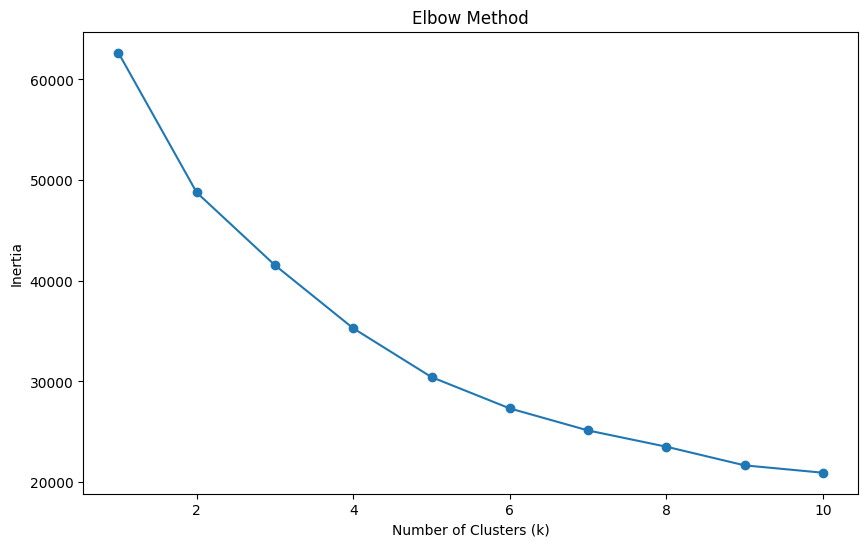

In [62]:
# หาจุดหักศอก Elbow Method
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

เลือกจุดหักที่ K = 4 แทนที่จะเลือกจุดที่หักเยอะสุด (K=7)
เพราะกลุ่มที่แบ่งจะไม่เล็กเกิน
ได้ว่ากลุ่มลูกค้าแตกต่างกัน 4 กลุ่ม

In [63]:
# Training
kmeans = KMeans(n_clusters=4, random_state=42)
df_credit['cluster'] = kmeans.fit_predict(scaled_data)

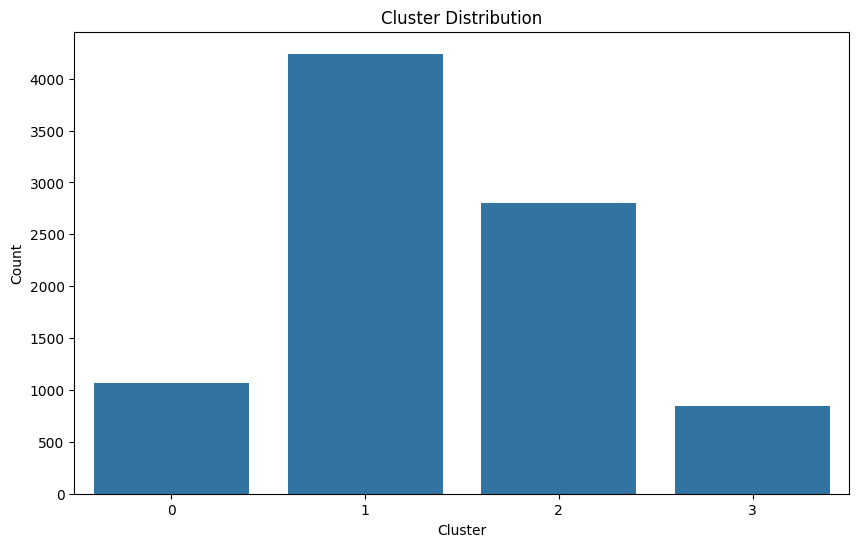

In [64]:
# cluster distribution plot
plt.figure(figsize=(10, 6))
sb.countplot(x='cluster', data=df_credit)
plt.title('Cluster Distribution')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

กลุ่มลูกค้ากระจายตัวไม่สม่ำเสมอ แตกต่างกันในแต่ละกลุ่ม

In [65]:
# cluster profile table
cluster_profile = df_credit.groupby('cluster')[features].mean().round(4)
cluster_profile

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,credit_utilization,payment_ratio
cluster,,,,,,,
0,5766.1108,1393.0483,4411.3202,9567.9686,4166.8856,0.6221,0.9305
1,439.7780,624.6679,289.2342,3938.9796,871.5532,0.1167,1.2517
2,1892.2087,480.1710,874.3612,2529.5165,1052.0820,0.7928,0.7028
3,821.8042,4143.3178,455.3128,7388.1460,5242.0998,0.1222,11.0771


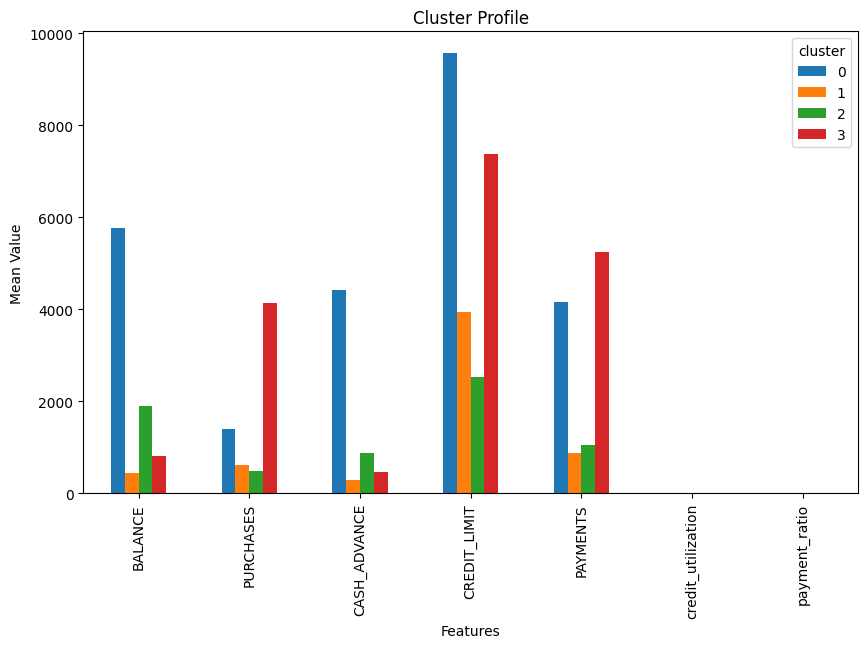

In [67]:
cluster_profile.T.plot(kind='bar', figsize=(10, 6))
plt.title('Cluster Profile')
plt.xlabel('Features')
plt.ylabel('Mean Value')
plt.show()

# Actionable Recommendations

1. กลุ่มความเสี่ยงสูง (High-Risk Revolvers: Cluster 2)

เป็นกลุ่มที่มีการใช้วงเงินเกือบเต็มวงเงิน มีการกดเงินสดสูง และมีสัดส่วนการชำระคืนต่ำกว่ากลุ่มอื่น แสดงถึงการขาดสภาพคล่องทางการเงิน

Recommendation: ธนาคารควรใช้ระบบแจ้งเตือน
และระงับการเพิ่มวงเงิน
พร้อมทั้งรีบนำเสนอมาตรการปรับโครงสร้างหนี้ หรือเปลี่ยนยอดหนี้บัตรเครดิตเป็นสินเชื่อเงินผ่อนรายเดือน

เพื่อป้องกันการเกิดหนี้เสีย (NPL)

2. กลุ่มพึ่งพาสินเชื่อ ยอดหนี้สูง (Credit-Dependent: Cluster 0)

มียอดหนี้คงค้างและวงเงินสูง มีการพึ่งพาเงินสดล่วงหน้าบ้าง แต่ยังจ่ายชำระขั้นต่ำได้ ถือเป็นกลุ่มที่สร้างรายได้จากดอกเบี้ยให้กับธนาคาร

Recommendation: ควรเฝ้าระวังพฤติกรรมการกดเงินสดอย่างใกล้ชิด (Monitoring) ถ้ามีการจ่ายล่าช้า ควรเสนอแคมเปญรวมหนี้ (Debt Consolidation)

เพื่อช่วยบรรเทาภาระดอกเบี้ยให้ลูกค้ายังสามารถผ่อนชำระต่อไปได้

3. กลุ่มทั่วไป ประวัติการเงินดี (Responsible Customers: Cluster 1)

เป็นฐานลูกค้ากลุ่มใหญ่ที่สุด ใช้วงเงินน้อย
ไม่ค่อยกดเงินสด และมีวินัยในการจ่ายเต็มหรือมากกว่าขั้นต่ำ

Recommendation: นำเสนอแคมเปญส่งเสริมการขายแบบเจาะจง (Targeted Promotions)
อย่างการให้ Cash Back หรือคะแนนพิเศษเมื่อมียอดใช้จ่ายถึงเกณฑ์ที่กำหนด

เพื่อกระตุ้นยอดการใช้จ่าย (Active Usage) และรักษาฐานลูกค้าไว้ได้

4. กลุ่มลูกค้าพรีเมียม กำลังซื้อสูง (Premium Active: Cluster 3)

มียอดรูดซื้อสินค้าสูงที่สุดและมียอดหนี้คงค้างต่ำมาก เพราะลูกค้ามักจะชำระเต็มจำนวน เป็นกลุ่มที่สร้างรายได้จากค่าธรรมเนียมการรูดบัตรได้อย่างมาก

Recommendation: ควรเน้นการรักษาความสัมพันธ์ระยะยาว (Retention) โดยการเสนอสิทธิพิเศษระดับ VIP อัปเกรดหน้าบัตร
และนำเสนอผลิตภัณฑ์ทางการเงินอื่นๆ (Cross-selling) เช่น กองทุนรวม สินเชื่อบ้าน

เพื่อโอกาสในการสร้างรายได้เพิ่มเติม และสามารถปรับปรุงความพึงพอใจของลูกค้า
